In [3]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# --- 1. Blur (Sharpness) Analysis using Laplacian Variance ---
dataset_path = "../dataset"
blur_data = []

# Threshold for blurriness (Lower than this value indicates a blurry image)
# 100 is a common heuristic, but can be adjusted based on your dataset results.
blur_threshold = 100.0

if os.path.exists(dataset_path):
    print("Starting blur analysis...")
    for class_name in sorted(os.listdir(dataset_path)):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(".jpg"):
                    file_path = os.path.join(class_dir, f)
                    try:
                        # Read image in grayscale using OpenCV
                        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            # Calculate Laplacian variance (sharpness score)
                            sharpness_score = cv2.Laplacian(img, cv2.CV_64F).var()
                            blur_data.append({
                                "Class": class_name,
                                "File_Path": file_path,
                                "Blur_Score": sharpness_score
                            })
                        else:
                            print(f"Could not read image: {file_path}")
                    except Exception as e:
                        print(f"Error processing file {file_path}: {e}")

    df_blur = pd.DataFrame(blur_data)
    print(f"Total scanned images for blur analysis: {len(df_blur)}")
else:
    print(f"Error: {dataset_path} does not exist")

Starting blur analysis...
Total scanned images for blur analysis: 115431


In [2]:
# --- 2. Analyze and Filter Blurry Images ---
if 'df_blur' in locals() and not df_blur.empty:
    print("\n--- Blur Score Statistics ---")
    print(df_blur["Blur_Score"].describe())

    # Filter blurry images below the threshold
    blurry_images = df_blur[df_blur["Blur_Score"] < blur_threshold]
    print(f"\nNumber of blurry images (score < {blur_threshold}): {len(blurry_images)}")

    if not blurry_images.empty:
        print("\n--- Sample Blurry Images (Lowest Scores) ---")
        display(blurry_images.sort_values(by="Blur_Score").head(10))

    # Report summary
    print("\n" + "="*45)
    print("BLUR ANALYSIS REPORT")
    print("="*45)
    print(f"Total Images Analyzed    : {len(df_blur)}")
    print(f"Blurry Images Count      : {len(blurry_images)}")
    print(f"Percentage of Blurry Imgs: {(len(blurry_images) / len(df_blur)) * 100:.2f}%")
    print("="*45)


--- Blur Score Statistics ---
count    115431.000000
mean        198.607718
std         266.215637
min          25.003826
25%          70.695910
50%         117.655761
75%         191.805037
max        1842.188840
Name: Blur_Score, dtype: float64

Number of blurry images (score < 100.0): 47932

--- Sample Blurry Images (Lowest Scores) ---


,Class,File_Path,Blur_Score
64744,O,../dataset/O/O_0_4336.jpg,25.003826
7716,B,../dataset/B/B_0_6356.jpg,25.009321
6436,B,../dataset/B/B_0_1875.jpg,25.009355
91923,U,../dataset/U/U_0_3294.jpg,25.013325
83094,T,../dataset/T/T_0_2356.jpg,25.018473
74289,R,../dataset/R/R_0_748.jpg,25.018956
45278,J,../dataset/J/J_0_1854.jpg,25.027134
53723,L,../dataset/L/L_0_3480.jpg,25.033956
34745,H,../dataset/H/H_0_6771.jpg,25.036489
60198,N,../dataset/N/N_0_8629.jpg,25.036968



BLUR ANALYSIS REPORT
Total Images Analyzed    : 115431
Blurry Images Count      : 47932
Percentage of Blurry Imgs: 41.52%


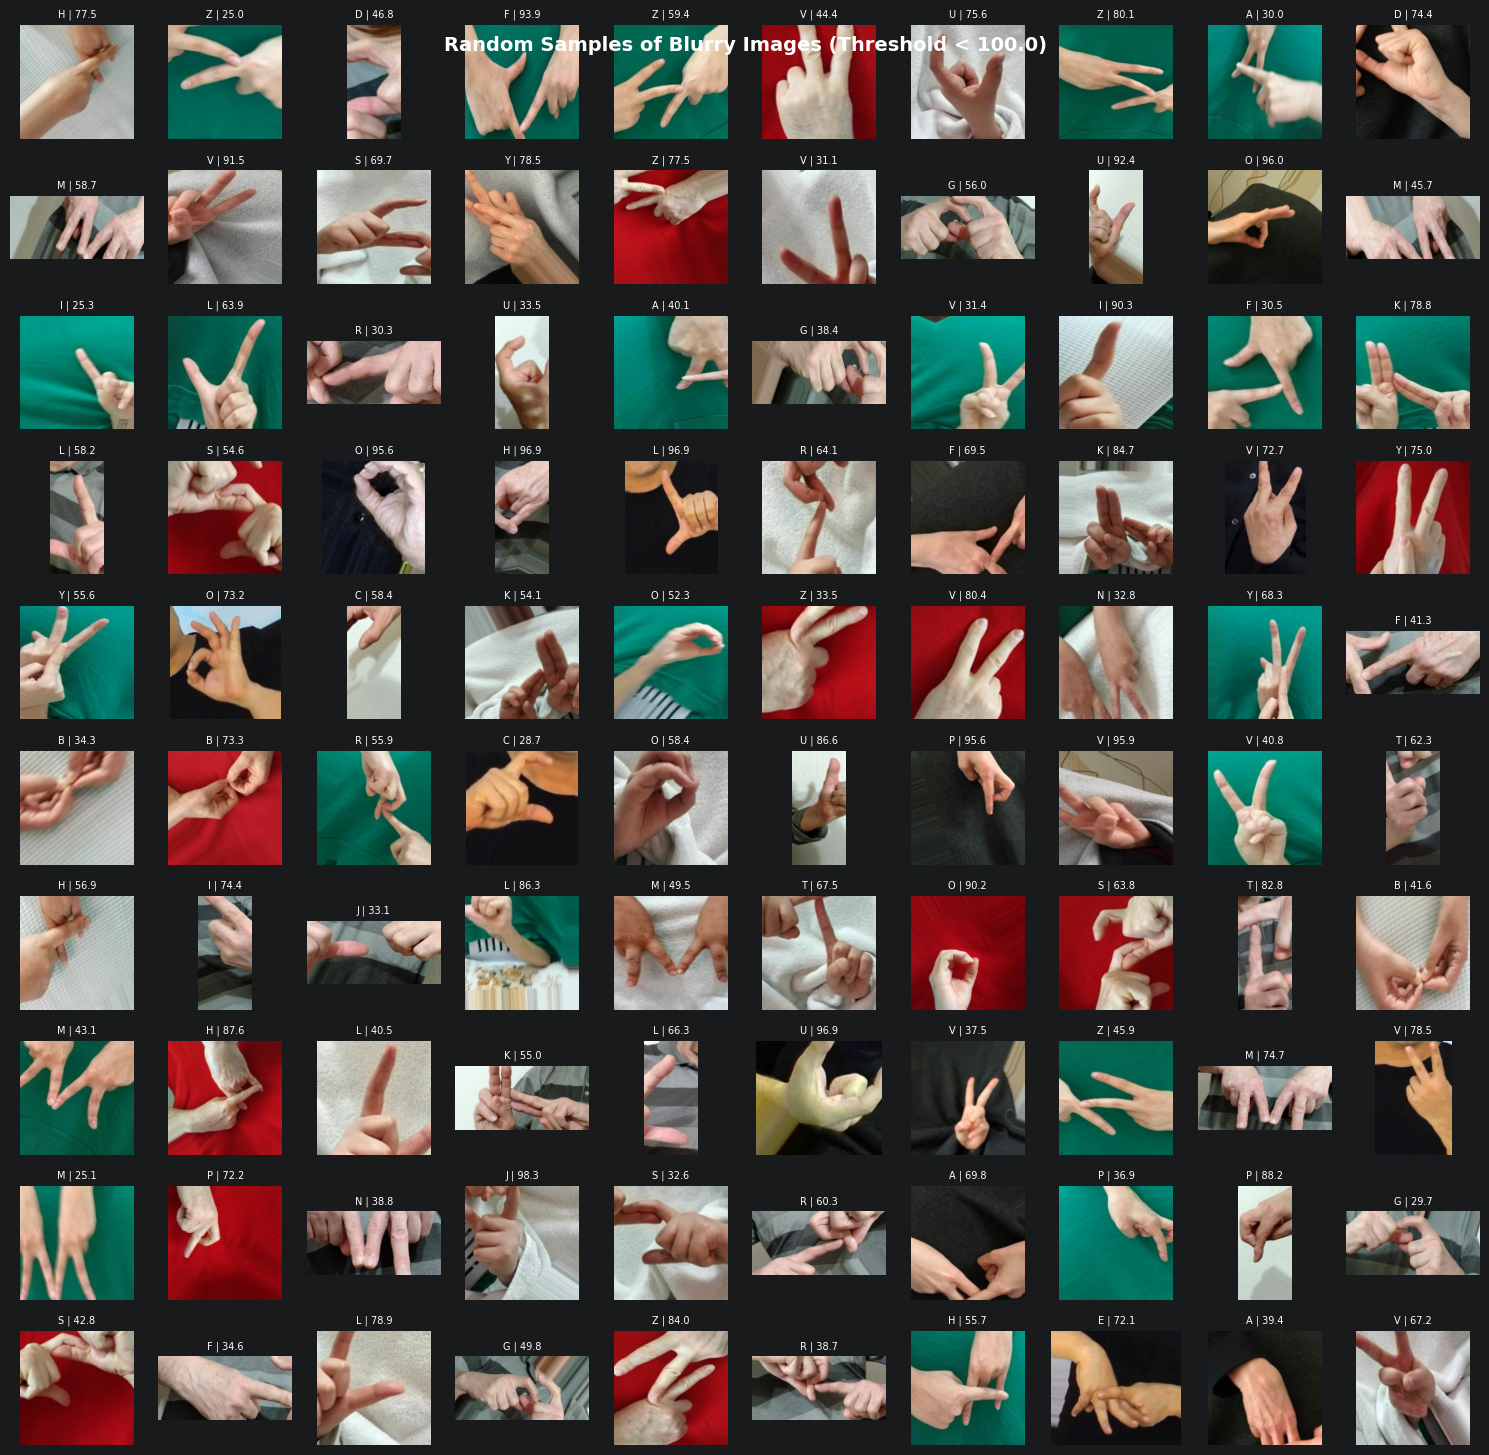

In [5]:
# --- Visualize Random Samples from Blurry Images (Below Threshold) ---
blur_threshold = 100.0

if 'df_blur' in locals() and not df_blur.empty:
    blurry_images = df_blur[df_blur["Blur_Score"] < blur_threshold]

    if not blurry_images.empty:
        num_to_show = min(100, len(blurry_images))

        sample_df = blurry_images.sample(n=num_to_show)

        grid_side = int(np.ceil(np.sqrt(num_to_show)))

        fig, axes = plt.subplots(grid_side, grid_side, figsize=(15, 15))
        axes = axes.flatten()

        for idx, row in enumerate(sample_df.itertuples()):
            ax = axes[idx]
            try:
                img = Image.open(row.File_Path)
                ax.imshow(img)
                ax.set_title(f"{row.Class} | {row.Blur_Score:.1f}", fontsize=7)
                ax.axis("off")
            except Exception as e:
                ax.text(0.5, 0.5, "Error Loading", ha='center', va='center')
                ax.axis("off")

        for j in range(len(sample_df), len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Random Samples of Blurry Images (Threshold < {blur_threshold})", fontsize=14, fontweight='bold', y=0.95)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No blurry images found below threshold {blur_threshold}.")
else:
    print("DataFrame 'df_blur' not found or empty. Run the blur analysis first.")

In [10]:
# --- Remove Blurry Images ---
# Set your finalized blur threshold here (e.g., 25.0 or whichever value gave your target count)
blur_threshold = 25.0

blurry_images = df_blur[df_blur["Blur_Score"] < blur_threshold]
removed_blur_count = 0

if not blurry_images.empty:
    print(f"--- Removing Blurry Images (Score < {blur_threshold}) ---")
    for row in blurry_images.itertuples():
        file_path = row.File_Path
        try:
            if os.path.exists(file_path):
                os.remove(file_path)
                removed_blur_count += 1
        except Exception as e:
            print(f"Error removing file {file_path}: {e}")

    print(f"\nSuccessfully removed {removed_blur_count} blurry images.")
else:
    print("No blurry images to remove based on the threshold.")

--- Removing Blurry Images (Score < 25.0) ---

Successfully removed 3907 blurry images.
